In [ ]:
!pip install kagglehub

import kagglehub
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as F

# Download dataset
path = kagglehub.dataset_download("anasmohammedtahir/covidqu")
print("Path to dataset files:", path)

lung_path = os.path.join(path, "Lung Segmentation Data", "Lung Segmentation Data")
print("Available splits:", os.listdir(lung_path))
train_path = os.path.join(lung_path, "Train")
print("Classes inside Train:", os.listdir(train_path))


Using Colab cache for faster access to the 'covidqu' dataset.
Path to dataset files: /kaggle/input/covidqu
Available splits: ['Val', 'Test', 'Train']
Classes inside Train: ['Non-COVID', 'Normal', 'COVID-19']


In [ ]:
lung_path = os.path.join(path, "Lung Segmentation Data")
print("Inside Lung Segmentation Data:", os.listdir(lung_path))
lung_data_path = os.path.join(lung_path, "Lung Segmentation Data")
print("Available splits:", os.listdir(lung_data_path))
train_path = os.path.join(lung_data_path, "Train")
print("Classes inside Train:", os.listdir(train_path))

#inside one class
covid_path = os.path.join(train_path, "COVID-19")
print("COVID-19 folders:", os.listdir(covid_path))

Inside Lung Segmentation Data: ['Lung Segmentation Data']
Available splits: ['Val', 'Test', 'Train']
Classes inside Train: ['Non-COVID', 'Normal', 'COVID-19']
COVID-19 folders: ['lung masks', 'images']


EDA

Available Classes: ['Non-COVID', 'Normal', 'COVID-19']
Non-COVID: 7208 images
Normal: 6849 images
COVID-19: 7658 images

Displaying random samples...



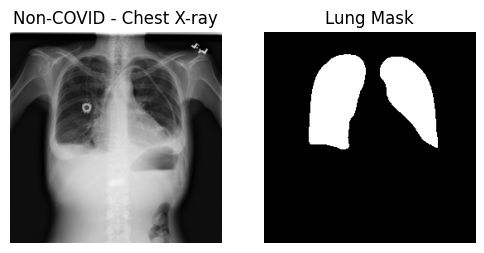

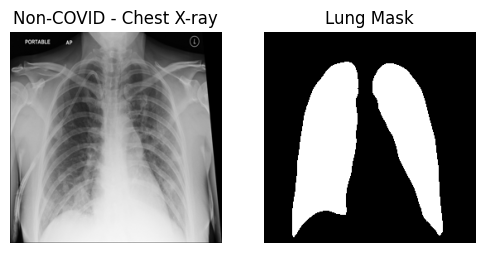

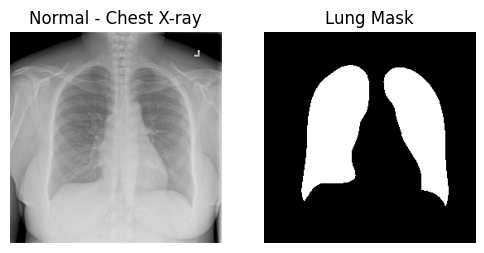

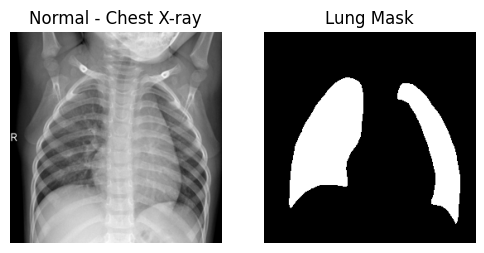

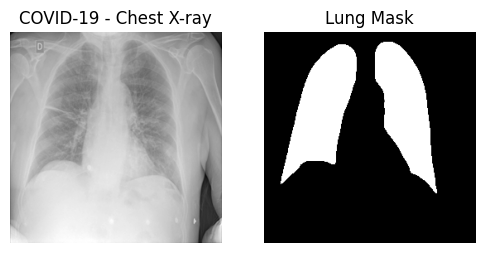

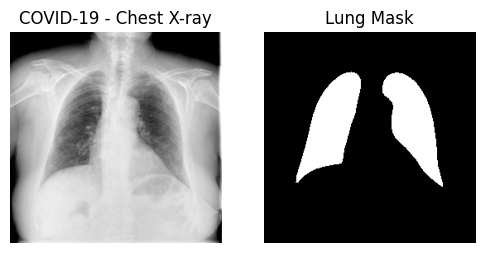

In [ ]:
import os, random
import matplotlib.pyplot as plt
from PIL import Image

def show_samples_per_class(root_dir, split="Train", n=3):
    split_dir = os.path.join(root_dir, split)
    class_names = os.listdir(split_dir)
    print("Available Classes:", class_names)
    print("="*50)

    # Show dataset distribution
    for cls in class_names:
        img_dir = os.path.join(split_dir, cls, "images")
        num_imgs = len(os.listdir(img_dir))
        print(f"{cls}: {num_imgs} images")

    print("\nDisplaying random samples...\n")

    # Plot n samples from each class
    for cls in class_names:
        img_dir = os.path.join(split_dir, cls, "images")
        mask_dir = os.path.join(split_dir, cls, "lung masks")
        img_files = os.listdir(img_dir)
        mask_files = os.listdir(mask_dir)

        for i in range(n):
            idx = random.randint(0, len(img_files)-1)
            img = Image.open(os.path.join(img_dir, img_files[idx])).convert("L")
            mask = Image.open(os.path.join(mask_dir, mask_files[idx])).convert("L")

            plt.figure(figsize=(6,3))
            plt.subplot(1,2,1)
            plt.imshow(img, cmap="gray")
            plt.title(f"{cls} - Chest X-ray")
            plt.axis("off")

            plt.subplot(1,2,2)
            plt.imshow(mask, cmap="gray")
            plt.title("Lung Mask")
            plt.axis("off")
            plt.show()

show_samples_per_class(lung_data_path, split="Train", n=2)


In [ ]:
import torch
from torchvision import transforms

# ImageNet normalization values
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Preprocessing for input images
base_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Lambda(lambda img: img.convert("RGB")),  # convert grayscale -> 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Preprocessing for masks
mask_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


data augmentation


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F

class ChestXrayClassificationDataset(Dataset):
    def __init__(self, img_dir, label, augment=False):
        self.img_dir = img_dir
        self.img_files = sorted(os.listdir(img_dir))
        self.label = label
        self.augment = augment

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.img_files[idx])).convert("L")
        if self.augment:
            if random.random() > 0.5:
                img = F.hflip(img)
            if random.random() > 0.5:
                angle = random.randint(-10, 10)
                img = F.rotate(img, angle)
            if random.random() > 0.5:
                img = F.adjust_contrast(img, random.uniform(0.9, 1.2))
        img = base_transform(img)
        return img, self.label


Without augmentation:


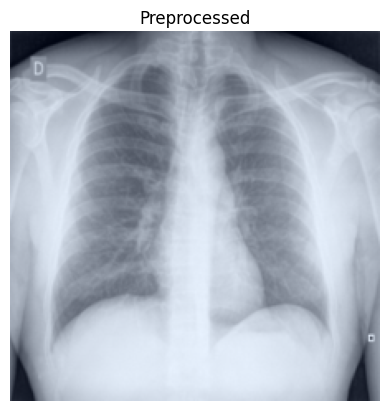

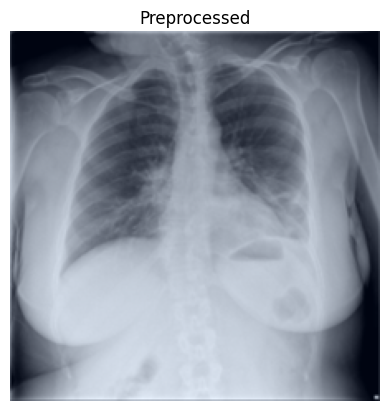

With augmentation:


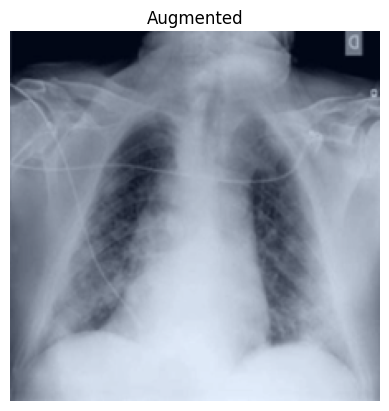

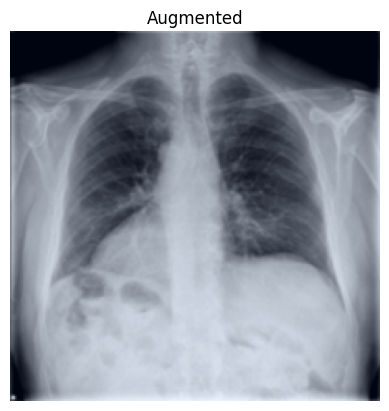

In [ ]:
def visualize_classification_dataset(img_dir, n=3, augment=False):
    dataset = ChestXrayClassificationDataset(img_dir, label=0, augment=augment)
    for i in range(n):
        img, _ = dataset[random.randint(0, len(dataset)-1)]

        # Convert back to numpy for plotting
        img_np = img.permute(1,2,0).numpy()

        plt.imshow((img_np - img_np.min()) / (img_np.max() - img_np.min()))
        plt.title("Augmented" if augment else "Preprocessed")
        plt.axis("off")
        plt.show()

# Example: visualize COVID-19 class
covid_img_dir = os.path.join(train_path, "COVID-19", "images")

print("Without augmentation:")
visualize_classification_dataset(covid_img_dir, n=2, augment=False)

print("With augmentation:")
visualize_classification_dataset(covid_img_dir, n=2, augment=True)


EfficientNet B0 using Pytorch


In [ ]:
!pip install efficientnet_pytorch

import torch
import torch.nn as nn
import torch.optim as optim
from efficientnet_pytorch import EfficientNet
from torch.utils.data import DataLoader


In [ ]:
from torch.utils.data import ConcatDataset

batch_size = 16

def get_dataloaders(split="Train", augment=False):
    class_dirs = os.listdir(os.path.join(lung_data_path, split))
    datasets = []
    for i, cls in enumerate(class_dirs):
        img_dir = os.path.join(lung_data_path, split, cls, "images")
        ds = ChestXrayClassificationDataset(img_dir, i, augment=augment)
        datasets.append(ds)

    full_dataset = ConcatDataset(datasets)
    loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    return loader, class_dirs

train_loader, class_names = get_dataloaders("Train", augment=True)
val_loader, _ = get_dataloaders("Val", augment=False)
test_loader, _ = get_dataloaders("Test", augment=False)

print("Classes:", class_names)


Classes: ['Non-COVID', 'Normal', 'COVID-19']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNet.from_pretrained("efficientnet-b0")
num_features = model._fc.in_features
model._fc = nn.Linear(num_features, len(class_names))  # 3 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


Loaded pretrained weights for efficientnet-b0


In [ ]:
def train_model(model, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        val_acc = evaluate_model(model, val_loader)

        print(f"Epoch {epoch+1}/{epochs}, "
              f"Loss: {running_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.4f}, "
              f"Val Acc: {val_acc:.4f}")

def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# run for 10 epochs
train_model(model, train_loader, val_loader, epochs=10)

# Save trained model
torch.save(model.state_dict(), "covidqu_model.pth")
print("Model saved as covidqu_model.pth")

Epoch 1/10, Loss: 0.3950, Train Acc: 0.8463, Val Acc: 0.9418
Epoch 2/10, Loss: 0.2413, Train Acc: 0.9069, Val Acc: 0.9487
Epoch 3/10, Loss: 0.2014, Train Acc: 0.9220, Val Acc: 0.9476
Epoch 4/10, Loss: 0.1739, Train Acc: 0.9340, Val Acc: 0.9561
Epoch 5/10, Loss: 0.1565, Train Acc: 0.9420, Val Acc: 0.9503
Epoch 6/10, Loss: 0.1476, Train Acc: 0.9460, Val Acc: 0.9531
Epoch 7/10, Loss: 0.1333, Train Acc: 0.9505, Val Acc: 0.9435
Epoch 8/10, Loss: 0.1142, Train Acc: 0.9584, Val Acc: 0.9465
Epoch 9/10, Loss: 0.1044, Train Acc: 0.9612, Val Acc: 0.9442
Epoch 10/10, Loss: 0.0927, Train Acc: 0.9657, Val Acc: 0.9479
Model saved as covidqu_model.pth


Evaluation metrics

Classification Report:
              precision    recall  f1-score   support

   Non-COVID       0.93      0.97      0.95      2253
      Normal       0.95      0.92      0.93      2140
    COVID-19       1.00      0.98      0.99      2395

    accuracy                           0.96      6788
   macro avg       0.96      0.96      0.96      6788
weighted avg       0.96      0.96      0.96      6788



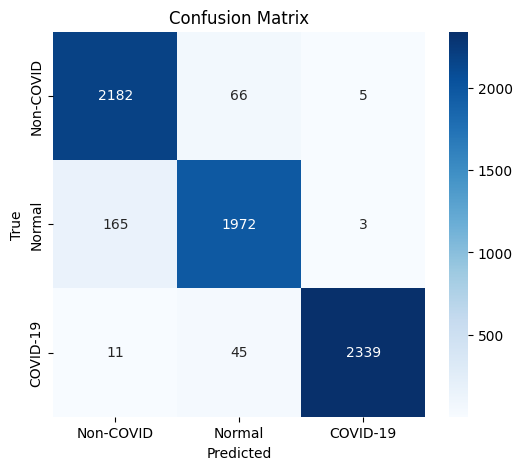


Sensitivity (per class):
Non-COVID: 0.9685
Normal: 0.9215
COVID-19: 0.9766

Specificity (per class):
Non-COVID: 0.9612
Normal: 0.9761
COVID-19: 0.9982

AUROC (per class):
Non-COVID: 0.9935
Normal: 0.9901
COVID-19: 0.9992

Macro-average AUROC: 0.9943


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

y_true = []
y_pred = []
y_prob = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# cm
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

sensitivity = []
specificity = []

for i in range(len(class_names)):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sens = TP / (TP + FN + 1e-8)
    spec = TN / (TN + FP + 1e-8)

    sensitivity.append(sens)
    specificity.append(spec)

print("\nSensitivity (per class):")
for i, s in enumerate(sensitivity):
    print(f"{class_names[i]}: {s:.4f}")

print("\nSpecificity (per class):")
for i, s in enumerate(specificity):
    print(f"{class_names[i]}: {s:.4f}")

#auroc
y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
auroc_ovr = roc_auc_score(y_true_bin, y_prob, average=None, multi_class='ovr')

print("\nAUROC (per class):")
for i, auc in enumerate(auroc_ovr):
    print(f"{class_names[i]}: {auc:.4f}")

print(f"\nMacro-average AUROC: {auroc_ovr.mean():.4f}")


AUROC

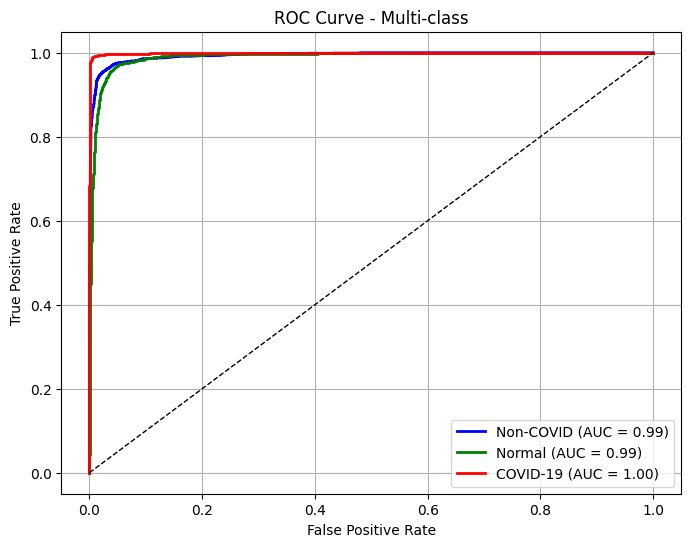

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get predictions and true labels
model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)


y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
n_classes = y_true_bin.shape[1]


fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))
colors = ['blue', 'green', 'red']
for i, cls in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{cls} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-class")
plt.legend(loc="lower right")
plt.grid()
plt.show()

gradcam on 1 img

Loaded pretrained weights for efficientnet-b0


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


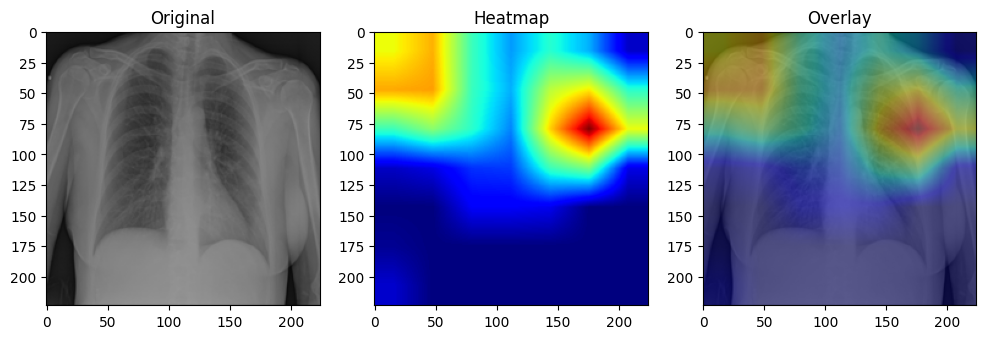

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

from efficientnet_pytorch import EfficientNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNet.from_pretrained("efficientnet-b0")
num_features = model._fc.in_features
model._fc = torch.nn.Linear(num_features, 3)  # 3 classes

# Load trained weights
model.load_state_dict(torch.load("covidqu_model.pth", map_location=device))
model = model.to(device)
model.eval()

# Pick last layer of EfficientNet
target_layer = model._conv_head


transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# pick 1 eg img
img_path = os.path.join(
    lung_data_path, "Train", "COVID-19", "images",
    os.listdir(os.path.join(lung_data_path, "Train", "COVID-19", "images"))[0]
)

img = Image.open(img_path).convert("RGB")
input_tensor = transform(img).unsqueeze(0).to(device)

activations, grads = [], []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    grads.append(grad_output[0])

handle_f = target_layer.register_forward_hook(forward_hook)
handle_b = target_layer.register_backward_hook(backward_hook)

output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

model.zero_grad()
score = output[0, pred_class]
score.backward()

grad = grads[0].mean(dim=(2,3), keepdim=True)   # GAP
cam = torch.sum(grad * activations[0], dim=1).squeeze()

cam = torch.relu(cam)
cam = cam - cam.min()
cam = cam / cam.max()
cam = cam.detach().cpu().numpy()

#visualize
import cv2

cam = cam - np.min(cam)
cam = cam / np.max(cam)

cam_resized = cv2.resize(cam, (224, 224))

heatmap = plt.cm.jet(cam_resized)[..., :3]  # shape (224,224,3)

img_resized = np.array(img.resize((224,224))) / 255.0
overlay = 0.4 * heatmap + 0.6 * img_resized

# Plot
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img_resized); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(heatmap); plt.title("Heatmap")
plt.subplot(1,3,3); plt.imshow(overlay); plt.title("Overlay")
plt.show()


# cleanup
handle_f.remove()
handle_b.remove()


save model on drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/covidqu_model.pth')


In [ ]:
from efficientnet_pytorch import EfficientNet
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNet.from_pretrained("efficientnet-b0")
num_features = model._fc.in_features
model._fc = torch.nn.Linear(num_features, 3)
model.load_state_dict(torch.load('/content/drive/MyDrive/covidqu_model.pth', map_location=device))
model = model.to(device)
model.eval()


Loaded pretrained weights for efficientnet-b0


EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        32, 8, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        8, 32, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False
    

grad cam on 1 image

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


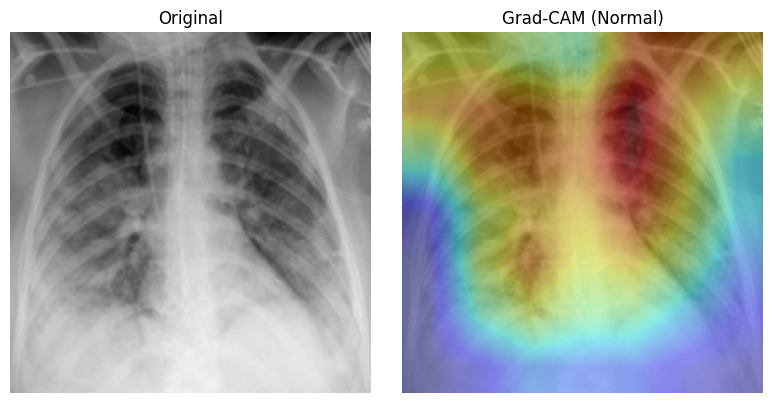

Saved Grad-CAM: gradcam_results/covid_test1_gradcam.png


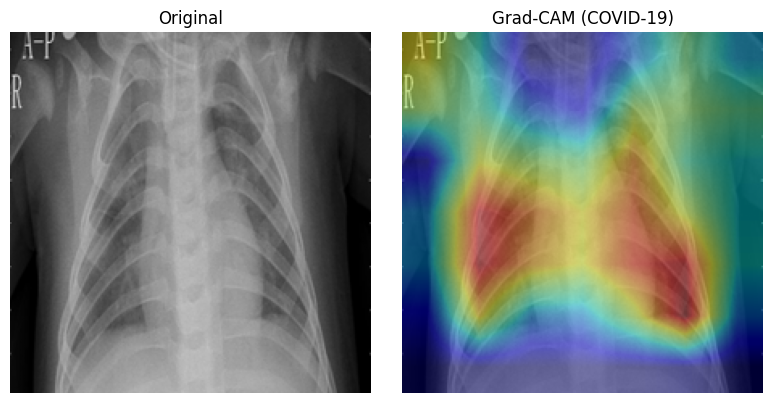

Saved Grad-CAM: gradcam_results/non_COVID_test_gradcam.png


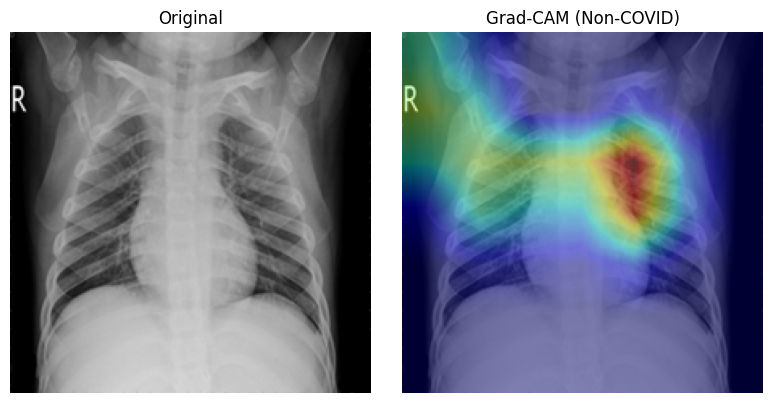

Saved Grad-CAM: gradcam_results/Normal_test_gradcam.png


In [ ]:
def generate_gradcam(img_path, save_path=None):
    img = Image.open(img_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    activations, grads = [], []

    def forward_hook(module, input, output):
        activations.append(output)
    def backward_hook(module, grad_input, grad_output):
        grads.append(grad_output[0])

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)

    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    class_names = ['COVID-19', 'Non-COVID', 'Normal']
    pred_label = class_names[pred_class]

    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    grad = grads[0].mean(dim=(2,3), keepdim=True)
    cam = torch.sum(grad * activations[0], dim=1).squeeze()
    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / cam.max()
    cam = cam.detach().cpu().numpy()

    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = plt.cm.jet(cam_resized)[..., :3]
    img_resized = np.array(img.resize((224, 224))) / 255.0
    overlay = 0.4 * heatmap + 0.6 * img_resized
    overlay = np.clip(overlay, 0, 1)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f"Grad-CAM ({pred_label})")
    plt.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    handle_f.remove()
    handle_b.remove()

covid_img = "covid_test1.jpg"
noncovid_img = "non_COVID_test.png"
normal_img = "Normal_test.png"

os.makedirs("gradcam_results", exist_ok=True)

for img_path in [covid_img, noncovid_img, normal_img]:
    filename = os.path.basename(img_path).split('.')[0]
    save_path = f"gradcam_results/{filename}_gradcam.png"
    generate_gradcam(img_path, save_path)
    print(f"Saved Grad-CAM: {save_path}")

Test on dataset: https://www.kaggle.com/datasets/sachinkumar413/covid-pneumonia-normal-chest-xray-images


In [ ]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("sachinkumar413/covid-pneumonia-normal-chest-xray-images")
print("Dataset path:", path)
print("Available folders:", os.listdir(path))

100%|██████████| 277M/277M [00:13<00:00, 21.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/sachinkumar413/covid-pneumonia-normal-chest-xray-images/versions/1
Available folders: ['COVID', 'PNEUMONIA', 'NORMAL']
